### Extraction of sample 3D area from the 3D plane

In [23]:
from pathlib import Path
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import stackview #for image processing and visualization 
import matplotlib.pyplot as plt
from pathlib import Path
BASE_DIR = Path.cwd().parent

In [29]:
# define which images to load

cnx = True
trpn = False
nuclei = False
merged_image = False

smaller_region = True
all_planes = True

# define region 
x_1 = 500
x_2 = 1000
y_1 = 500
y_2 = 1000
# z defines the number of planes to load, so if you want to load all planes, comment out
z_1 = 136
z_2 = 237
# if all_planes == True:
#     z_2 = ""
#     z_1 = ""


final_planes_list  = []

In [30]:
full_image_path = Path(BASE_DIR/'data/corrected_images')

In [32]:
# load whole image 
# setting image path 
if smaller_region: 
    out_path = Path(BASE_DIR/'data/seperate_planes/small_region')
if cnx: 
    cnx_image = io.imread(Path(full_image_path/'cnx43.tif')) # read image 
    io.imsave(out_path/f"cnx_{z_2, x_1, x_2}.tiff", cnx_image[z_1:z_2,y_1:y_2, x_1:x_2]) # save plane to folder 
    final_planes_list.append(cnx_image)
if trpn: 
    trpn_image = io.imread(Path(full_image_path/'cTnT.tif')) # read image 
    io.imsave(out_path/f"trpn_{all_planes, x_1, x_2}.tiff", trpn_image[:,y_1:y_2, x_1:x_2]) # save plane to folder #z_1:z_2, 
    final_planes_list.append(trpn_image)
if nuclei:
    nuclei_image = io.imread(Path(full_image_path/'nuclei.tif')) # read image 
    io.imsave(out_path/f"nuclei_{all_planes, x_1, x_2}.tiff", nuclei_image[:,y_1:y_2, x_1:x_2]) # save plane to folder 
    final_planes_list.append(nuclei_image)


In [22]:
cnx_image[:,y_1:y_2, x_1:x_2].shape

(510, 500, 500)

NameError: name 'trpn_image' is not defined

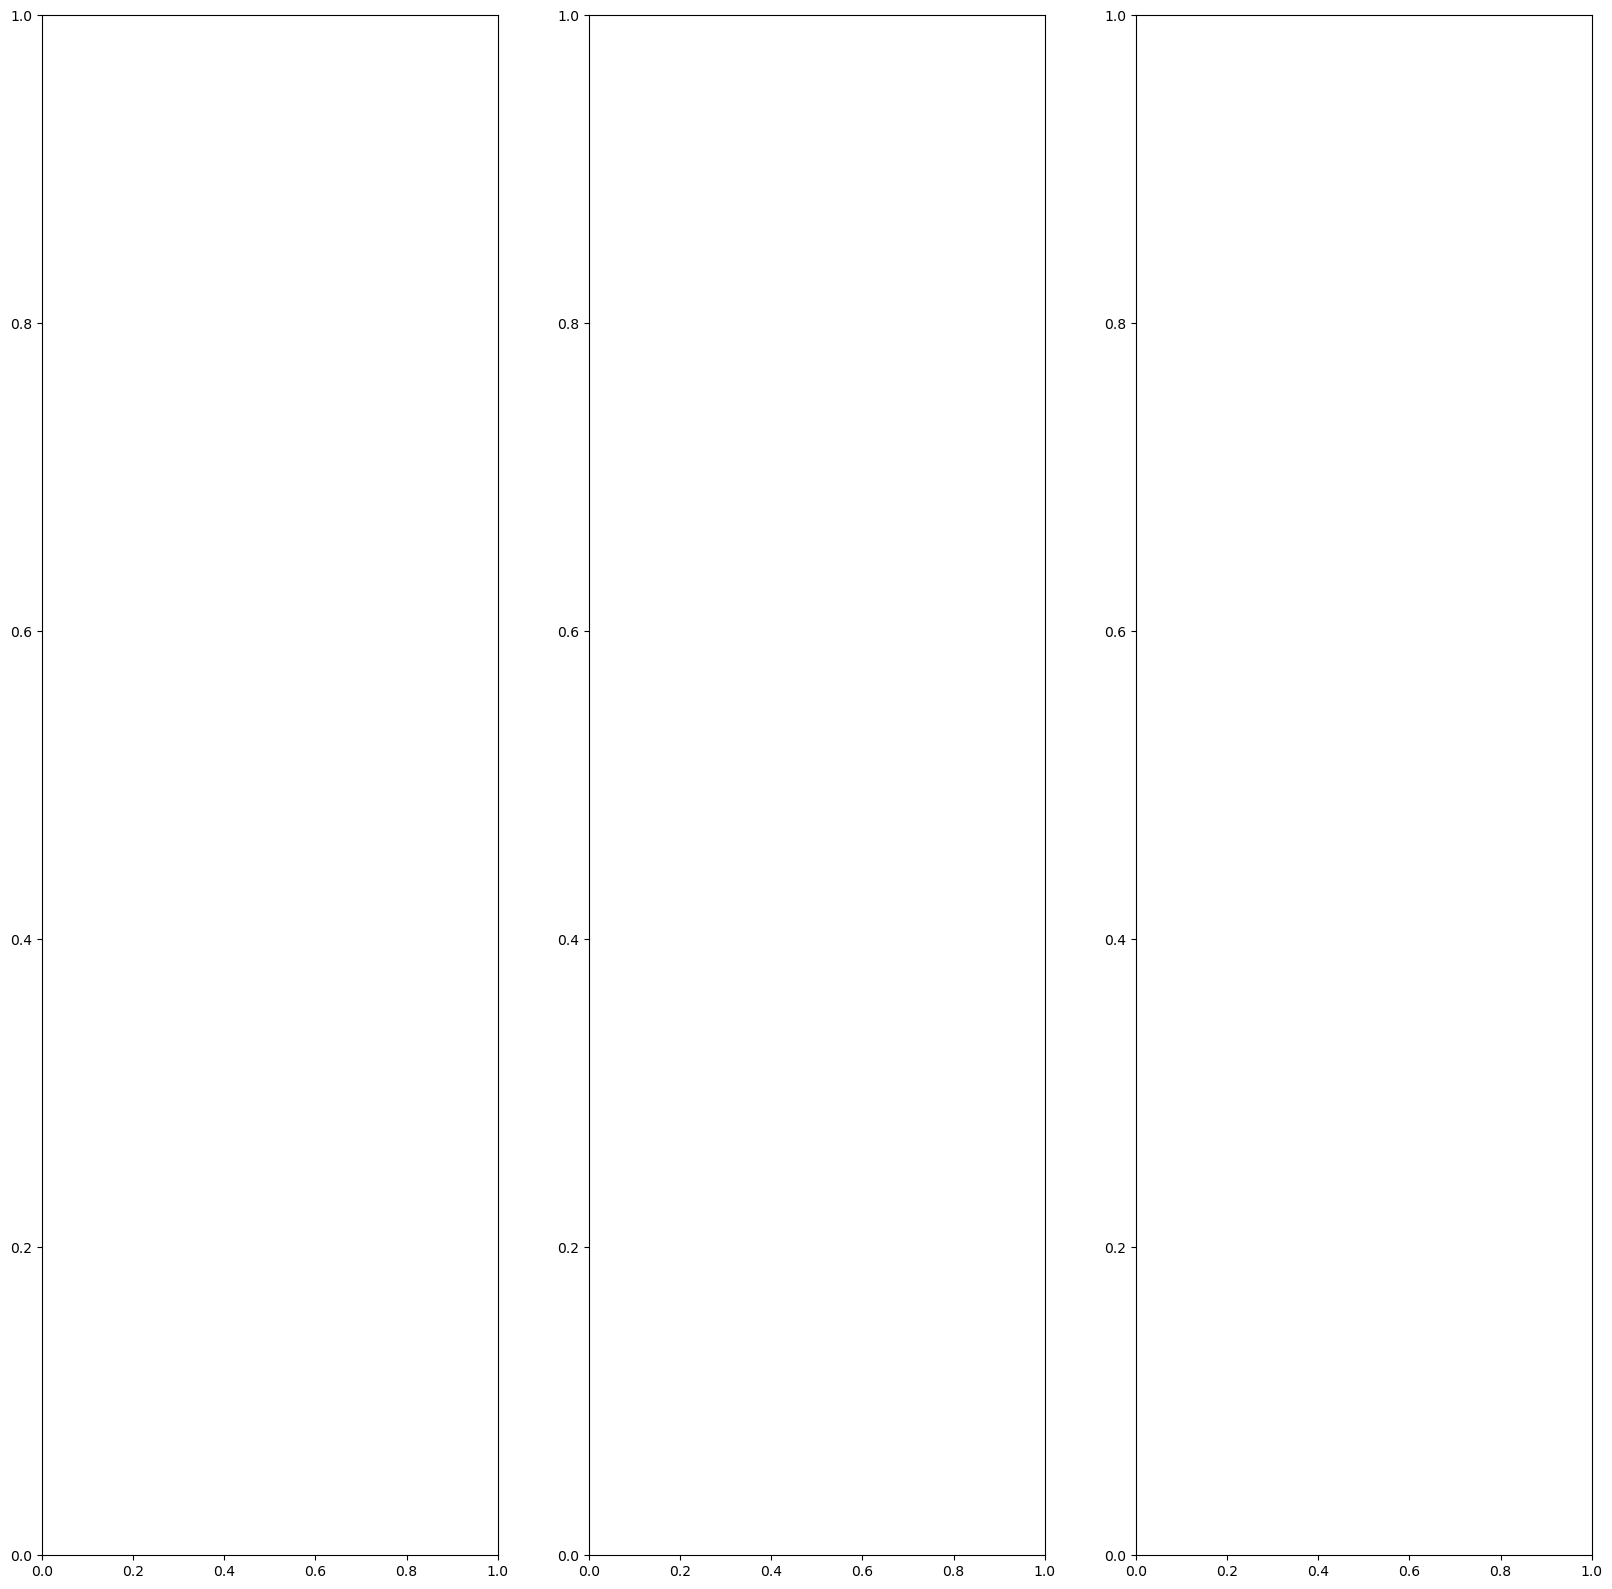

In [ ]:
# visualize sample planes

# from matplotlib import axis


fig, axs = plt.subplots(1, 3, figsize=(20,20))
final_planes_list = [cnx_image, trpn_image, nuclei_image]
for i, image in enumerate(final_planes_list):
    axis = axs[i]
    stackview.imshow(image = image[254][y_1:y_2, x_1:x_2], plot=axis)
    
    

### Extract PSF 

In [26]:
import h5py

In [25]:
psf_path = 'PSF_488nm_cnx.h5'
psf_name = 'PSF_488'

In [27]:
# open the psf file 
with h5py.File(BASE_DIR/'data/experimental_PSF'/psf_path, "r") as f:
    psf = f[f'{psf_name}/ImageData/Image'][:]
    psf_info = f[f'{psf_name}/ImageData/Image']
    # f.visit(print) # show all keys

    # find out what axis corresponds the which scale: 
    print("shape:", psf_info.shape)
    print("number of dims:", len(psf_info.dims))

    for i, dim in enumerate(psf_info.dims):
        print("axis", i, "number of attached scales:", len(dim))

shape: (1, 1, 192, 40, 40)
number of dims: 5
axis 0 number of attached scales: 0
axis 1 number of attached scales: 1
axis 2 number of attached scales: 1
axis 3 number of attached scales: 1
axis 4 number of attached scales: 1


In [28]:
# save to new file 
io.imsave(out_path/f"{psf_name}.tiff", psf) # save plane to folder

c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: C:\Users\laura\OneDrive\Dokumente\Bewerbungen\Master_Leipzig\Auslandssemester\Tampere\Semester 5\Master_Thesis\Project\data\seperate_planes\small_region\PSF_488.tiff is a low contrast image
  return func(*args, **kwargs)
